# Spam Mail Detection using Machine Learning

## Objective

The objective of this project is to classify SMS messages into Spam and Ham (Not Spam) using Natural Language Processing (NLP) techniques and Machine Learning.

## Algorithm Used

- Multinomial Naive Bayes

## Feature Extraction

- TF-IDF Vectorizer

## Tools Used

- Python
- Google Colab
- Pandas
- Scikit-learn
- Matplotlib
- Seaborn

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# Load dataset
df = pd.read_csv("spam.csv", encoding="latin-1")

# Keep only useful columns
df = df[['v1', 'v2']]

# Rename columns
df.columns = ['Label', 'Message']

# Display first 5 rows
df.head()

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# Display first 5 rows
print("First 5 Rows:")
display(df.head())

# Display last 5 rows
print("\nLast 5 Rows:")
display(df.tail())

# Shape of dataset
print("\nShape of Dataset:")
print(df.shape)

# Column names
print("\nColumn Names:")
print(df.columns)

# Dataset Information
print("\nDataset Information:")
df.info()

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Count spam and ham messages
print("\nMessage Counts:")
print(df['Label'].value_counts())

First 5 Rows:


,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Last 5 Rows:


,Label,Message
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name



Shape of Dataset:
(5572, 2)

Column Names:
Index(['Label', 'Message'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Label    5572 non-null   object
 1   Message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB

Missing Values:
Label      0
Message    0
dtype: int64

Message Counts:
Label
ham     4825
spam     747
Name: count, dtype: int64


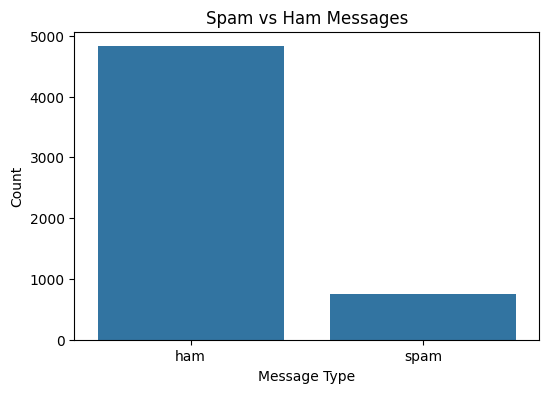

In [ ]:
# Plot the number of spam and ham messages

plt.figure(figsize=(6,4))

sns.countplot(x='Label', data=df)

plt.title("Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")

plt.show()

In [ ]:
# Convert labels into numbers

df['Label'] = df['Label'].map({
    'ham':0,
    'spam':1
})

# Display first five rows
df.head()

,Label,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# Input messages
X = df['Message']

# Output labels
y = df['Label']

print("Number of Messages:", X.shape)
print("Number of Labels:", y.shape)

Number of Messages: (5572,)
Number of Labels: (5572,)


In [ ]:
# Create TF-IDF Vectorizer
vectorizer = TfidfVectorizer(stop_words='english')

# Convert messages into numerical features
X = vectorizer.fit_transform(X)

print("Shape after TF-IDF:", X.shape)

Shape after TF-IDF: (5572, 8404)


In [ ]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (4457, 8404)
Testing Data: (1115, 8404)


In [ ]:
# Create the Multinomial Naive Bayes model
model = MultinomialNB()

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
# Predict on test data
y_pred = model.predict(X_test)

# Compare first 10 predictions
prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

prediction_df.head(10)

,Actual,Predicted
0,0,0
1,0,0
2,1,0
3,0,0
4,1,1
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 96.86 %


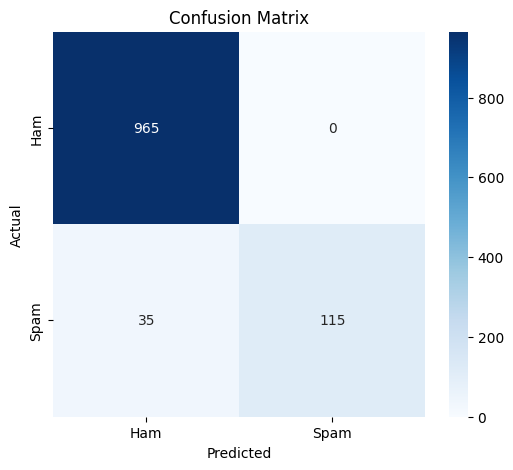

In [ ]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Ham","Spam"],
    yticklabels=["Ham","Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
# Print classification report
print(classification_report(
    y_test,
    y_pred,
    target_names=["Ham","Spam"]
))

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       965
        Spam       1.00      0.77      0.87       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.93      1115
weighted avg       0.97      0.97      0.97      1115



##Example


In [ ]:
# Test custom messages

messages = [
    "Congratulations! You have won a free iPhone. Click here to claim your prize.",
    "Hi Adarsh, are you coming to college tomorrow?"
]

# Convert messages using the same TF-IDF vectorizer
messages_vector = vectorizer.transform(messages)

# Predict
predictions = model.predict(messages_vector)

# Display results
for message, prediction in zip(messages, predictions):
    if prediction == 1:
        print(f"Message: {message}")
        print("Prediction: Spam\n")
    else:
        print(f"Message: {message}")
        print("Prediction: Ham\n")

Message: Congratulations! You have won a free iPhone. Click here to claim your prize.
Prediction: Spam

Message: Hi Adarsh, are you coming to college tomorrow?
Prediction: Ham



# Conclusion

In this project, a Spam Mail Detection system was developed using Natural Language Processing (NLP) and the Multinomial Naive Bayes algorithm.

The SMS Spam Collection dataset was explored and preprocessed. The text messages were converted into numerical features using the TF-IDF Vectorizer. The dataset was divided into training and testing sets, and the model was trained successfully.

The model achieved high accuracy in distinguishing spam and legitimate (ham) messages. It was further tested using custom messages, demonstrating its ability to classify unseen text effectively.

This project provided practical experience in text preprocessing, feature extraction, machine learning classification, and model evaluation using Python and Scikit-learn.